In [1]:
import numpy               as np
#import seaborn             as sns
import pandas              as pd
import libraries.plotting  as slp
import libraries.utilities as sul
import os

#sns.set_theme()

/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [2]:
# Define name to reference folder which stores the energies of each slab
material = 'SbSBr'
slab_folder = f'/Users/cibran/Desktop/slabs/{material}-slab/alignments/ranking-energies-as-in-slabs'
#slab_folder = 'input/ML-slabs/SbSBr'

The surface formation energy ($E_{surface}$) can be expressed in terms of the area ($S$) of the surface, the energy ($E_{slab}$) of the slab and the energy of the bulk system ($E_{bulk}$) as:

\begin{equation}
    E_{surface} = \frac{E_{slab} - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [3]:
bulk_folder = f'{slab_folder}/bulk'

# Load the bulk energy
bulk_energy = sul.read_energy(bulk_folder)

# Load bulk information
slab_data = sul.load_json(filename=f'{bulk_folder}/slab_data.json')

n_bulk = slab_data['number_of_sites']

/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/outputs.py:312: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:
/Users/cibran/work/UPC/SlabOptimization/.venv/lib/python3.13/site-packages/pymatgen/io/vasp/inputs.py:2655: EncodingWarning: We strongly encourage explicit `encoding`, and we would use UTF-8 by default as per PEP 686
  with zopen(filename, mode="rt") as file:


In [4]:
# Initialize the data dictionary for storing all slab energy calculations
# Iterate over slabs
surface_energies_of_formation = {}
for i, miller_index_str in enumerate(os.listdir(slab_folder)):
    # Define current folder
    miller_folder = f'{slab_folder}/{miller_index_str}'
    print(miller_folder)
    # Skip in case it is not a folder or it is the bulk folder
    if (not os.path.isdir(miller_folder)) or (miller_index_str == 'bulk'):
        continue

    # Load slab information
    slab_data = sul.load_json(filename=f'{miller_folder}/slab_data.json')

    print()
    print(f'Slab {i+1}')
    print()
    print(f'Miller index: {slab_data['miller_index']}')
    print(f'Shift: {slab_data['shift']:.3g}')
    print(f'Surface area: {slab_data['surface_area']:.3g}')
    print(f'Number of sites: {slab_data['number_of_sites']}')

    # Load the single-shot energy
    slab_energy = sul.read_energy(miller_folder)

    print(f'E_total = {slab_energy:.3g} eV')

    bulk_energy_times_fu = bulk_energy * slab_data['number_of_sites'] / n_bulk
    
    # Compute surface energy of formation in eV/atom/ang^2
    surface_energy_of_formation = sul.get_surface_energy_of_formation(slab_energy, bulk_energy_times_fu, slab_data['surface_area'])

    # Save the slab energy
    np.savetxt(f'{miller_folder}/surface_energy_of_formation', [surface_energy_of_formation])

    print(f'\t$E_surface$ = {surface_energy_of_formation:.3g} J/m²')

    # Generate a dictionary object with the new data and update in the main data object
    surface_energies_of_formation.update({
        miller_index_str: surface_energy_of_formation
    })

# Convert to Pandas DataFrame
surface_energies_of_formation = pd.DataFrame(surface_energies_of_formation, index=['energy'])

/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/ranking-energies-as-in-slabs/1_1_2_i_57

Slab 1

Miller index: [1, 1, 2]
Shift: 6.66e-15
Surface area: 106
Number of sites: 96
E_total = -386 eV
	$E_surface$ = 0.253 J/m²
/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/ranking-energies-as-in-slabs/ranking.png
/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/ranking-energies-as-in-slabs/1_1_2_i_58

Slab 3

Miller index: [1, 1, 2]
Shift: 0.3
Surface area: 106
Number of sites: 96
E_total = -384 eV
	$E_surface$ = 0.43 J/m²
/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/ranking-energies-as-in-slabs/bulk
/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/ranking-energies-as-in-slabs/.DS_Store
/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/ranking-energies-as-in-slabs/2_1_2_i_31

Slab 6

Miller index: [2, 1, 2]
Shift: 5.33e-15
Surface area: 171
Number of sites: 144
E_total = -578 eV
	$E_surface$ = 0.303 J/m²
/Users/cibran/Desktop/slabs/SbSBr-slab/alignments/ranking-energies-as-in-slabs

# Extract local minimas and generate input files

In [5]:
min_arg      = np.argsort(surface_energies_of_formation.values)[0]
local_minima = surface_energies_of_formation.columns[min_arg]
energies     = surface_energies_of_formation.values[0][min_arg]
local_minima, energies

(Index(['0_1_1_i_18', '0_1_0_i_21', '0_2_1_i_63', '1_1_2_i_57', '1_2_0_i_54',
        '1_2_2_i_49', '2_1_2_i_31', '2_1_0_i_41', '2_0_1_i_44', '1_1_2_i_58'],
       dtype='object'),
 array([0.08333466, 0.09946737, 0.23274849, 0.25297283, 0.26794689,
        0.28015783, 0.30324273, 0.32308293, 0.33521707, 0.43041869]))

In [6]:
min_arg_sort = surface_energies_of_formation.T.sort_values(by='energy', ascending=True)
min_arg_sort.to_excel(f'{slab_folder}/{material}-sorted_data.xlsx')

In [7]:
import seaborn as sns
sns.set_style("whitegrid")

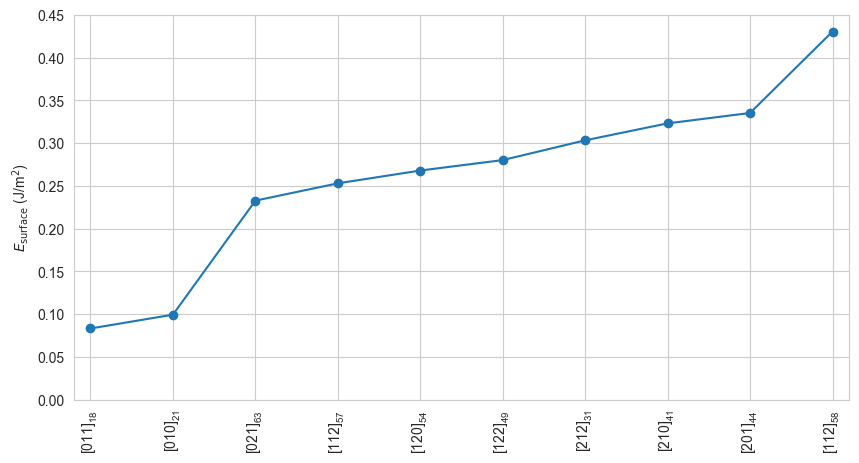

In [8]:
slp.plot_ranking(surface_energies_of_formation,
                 ylabel=r'$E_{\text{surface}}$ (J/m$^2$)',
                 filename=f'{slab_folder}/ranking.png', dpi=300)